# Testing the Integrated Gradient Framework on InterpreMol trained on Collins 39k SA

In [1]:
import sys 

sys.path.append("../model")
from model import InterpreMol
from rdkit import Chem
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model = InterpreMol.load("../checkpoints/first_Collins_SA_InterpreMol_model.pt", device=device)
model.eval()  # Optional but good practice


InterpreMol(
  (encoder): GraphEncoder(
    (featurizer): AtomFeaturizer(
      (atom_type_embedding): Embedding(46, 128)
      (degree_embedding): Embedding(6, 128)
      (charge_embedding): Embedding(11, 128)
      (hybridization_embedding): Embedding(3, 128)
      (num_h_embedding): Embedding(5, 128)
      (chirality_embedding): Embedding(4, 128)
      (scalar_proj): Linear(in_features=3, out_features=128, bias=True)
    )
    (model): GraphTransformerEncoder(
      (layers): ModuleList(
        (0-2): 3 x GraphTransformerBlock(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (ff): Sequential(
            (0): Linear(in_features=128, out_features=256, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.1, inplace=

In [2]:
def predict_smiles(smiles: str):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0
    with torch.no_grad():
        pred = model([mol])  # returns logits
        prob = torch.sigmoid(pred)  # only needed for binary classification
        return prob.item()

In [3]:
import pandas as pd

COADD_SA = pd.read_csv("../datasets/COADD_SA_cleaned.csv")
COADD_SA['pred'] = COADD_SA['SMILES'].apply(lambda x: predict_smiles(x))
COADD_SA

[12:14:56] Can't kekulize mol.  Unkekulized atoms: 11 12 13 14 15


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate_predictions(df, prediction_col="pred", truth_col="Hit", verbose=True):
    """
    Computes AUROC and AUPRC from a DataFrame with predictions and ground truth.

    Args:
        df (pd.DataFrame): Must contain columns for predictions and true labels.
        prediction_col (str): Name of the prediction column.
        truth_col (str): Name of the ground truth column.
        verbose (bool): If True, prints results.

    Returns:
        dict: Dictionary with AUROC and AUPRC scores.
    """
    y_true = df[truth_col].values
    y_score = df[prediction_col].values

    auroc = roc_auc_score(y_true, y_score)
    auprc = average_precision_score(y_true, y_score)

    if verbose:
        print(f"AUROC: {auroc:.4f}")
        print(f"AUPRC: {auprc:.4f}")

    return {"auroc": auroc, "auprc": auprc}


In [ ]:
COADD_SA.to_csv("../datasets/COADD_SA_predictions.csv", index=False)
results = evaluate_predictions(COADD_SA)

AUROC: 0.6794
AUPRC: 0.0650


For comparison when training on E.coli 

MiniMol: 
- AUROC:  0.8632
- AUPRC:  0.1544

Chemprop: 
- AUROC: 0.6331
- AUPRC: 0.0418

In [ ]:
import pandas as pd

Collins_SA = pd.read_csv("../datasets/Collins_SA_cleaned.csv")
Collins_SA['pred'] = Collins_SA['SMILES'].apply(lambda x: predict_smiles(x))
Collins_SA

,SMILES,Hit,pred
0,CC(N)C(O)c1ccccc1,0.0,0.774105
1,O=[N+]([O-])c1ccc(O)c([N+](=O)[O-])c1,1.0,0.956275
2,O=c1cc[nH]c(=S)[nH]1,0.0,0.063962
3,O=C(O)CCCN1C(=O)c2cccc3cccc(c23)C1=O,0.0,0.150912
4,Nc1nc(NC2CC2)c2ncn(C3C=CC(CO)C3)c2n1,0.0,0.838477
...,...,...,...
38169,Cc1c(C)c2c(c(C)c1O)CCC(C)(CCCC(C)CCCC(C)CCCC(C...,0.0,0.159060
38170,CC(=O)Oc1c(C)c(C)c2c(c1C)CCC(C)(CCCC(C)CCCC(C)...,0.0,0.026655
38171,CC(C=CC=C(C)C=CC1=C(C)CCCC1(C)C)=CC=CC=C(C)C=C...,0.0,0.125502
38172,C=C(C)C1CC=C(C)CC1,0.0,0.012706


In [ ]:
Collins_SA.to_csv("../datasets/Collins_SA_predictions.csv", index=False)
results = evaluate_predictions(Collins_SA)

AUROC: 0.8698
AUPRC: 0.2441


# Interpretability 

In [4]:
%load_ext autoreload

Attributions for SMILES: ClC1=CC=C2C(C(C(OC3=CC=C(C(O)=O)C=C3)C4=CC=C(Cl)C=C4)=CN2)=C1
  ➤ Min attribution: -1.2429
  ➤ Max attribution: 3.5798
  ➤ Mean attribution: 0.2451
  ➤ Attribution convergence delta: 0.000000


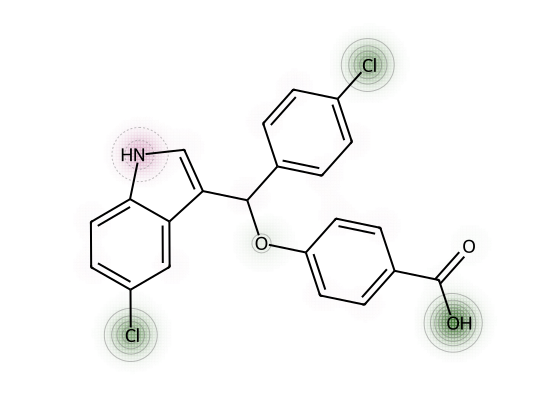

score: 0.8359833359718323


In [11]:
from interpret import interpret_smiles
%autoreload 2
# Example SMILES string
smiles = "ClC1=CC=C2C(C(C(OC3=CC=C(C(O)=O)C=C3)C4=CC=C(Cl)C=C4)=CN2)=C1"  # Aspirin

def interpret_from_smiles(smiles, model):
    score = predict_smiles(smiles)
    img, scores = interpret_smiles(smiles, model, target=0, bw=True)
    display(img)  # If in notebook
    print(f"score: {score}")   

interpret_from_smiles(smiles, model)

Attributions for SMILES: OC(C1=CN(C2=C1C=C(F)C=C2)C3=CC(NC(NC4CC5CCC4O5)=O)=CC(F)=C3)=O
  ➤ Min attribution: -2.3300
  ➤ Max attribution: 4.0078
  ➤ Mean attribution: 0.0840
  ➤ Attribution convergence delta: 0.000002


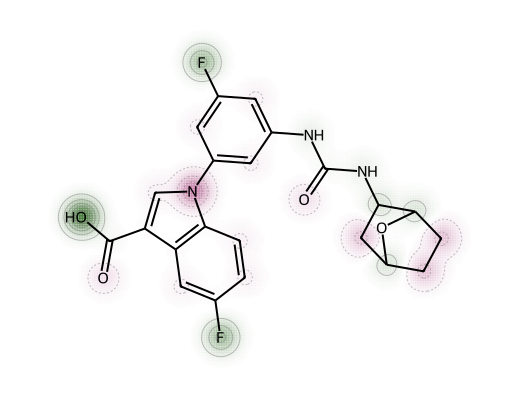

score: 0.067010298371315


In [12]:
interpret_from_smiles("OC(C1=CN(C2=C1C=C(F)C=C2)C3=CC(NC(NC4CC5CCC4O5)=O)=CC(F)=C3)=O", model)

Attributions for SMILES: ClC1=CC(OC2=CC=C(Cl)C=C2)=C(NC(CC3(CC(O)=O)CCCCC3)=O)C=C1
  ➤ Min attribution: -1.4989
  ➤ Max attribution: 2.7831
  ➤ Mean attribution: 0.1701
  ➤ Attribution convergence delta: -0.000000


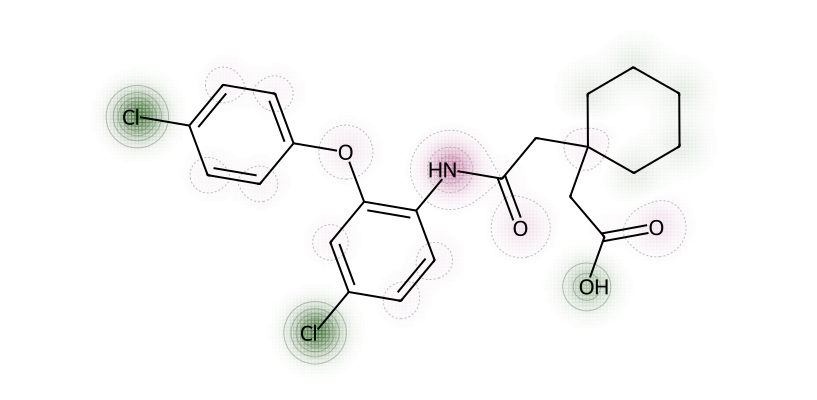

score: 0.42468976974487305


In [13]:
interpret_from_smiles("ClC1=CC(OC2=CC=C(Cl)C=C2)=C(NC(CC3(CC(O)=O)CCCCC3)=O)C=C1", model)

Attributions for SMILES: ClC1CC=C2C(C=C(C(O)=O)N2CCOC3=CC=C(F)C=C3)=C1
  ➤ Min attribution: -2.0083
  ➤ Max attribution: 5.5155
  ➤ Mean attribution: 0.1557
  ➤ Attribution convergence delta: 0.000017


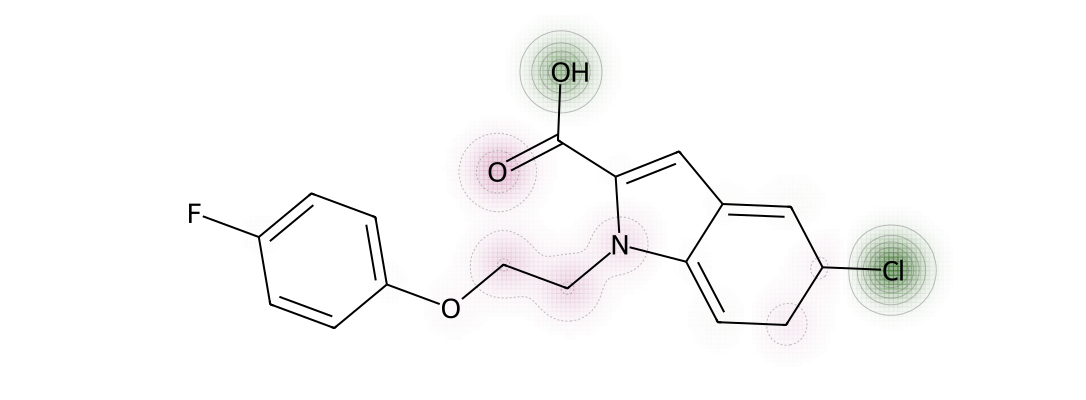

score: 0.16137968003749847


In [14]:
interpret_from_smiles("ClC1CC=C2C(C=C(C(O)=O)N2CCOC3=CC=C(F)C=C3)=C1", model)

Attributions for SMILES: OC(C1=NC=C(NC(NC2CCC(OC3=C(Cl)C=C(Cl)C=C3)CC2)=O)C=C1)=O
  ➤ Min attribution: -1.2736
  ➤ Max attribution: 2.0995
  ➤ Mean attribution: 0.1700
  ➤ Attribution convergence delta: -0.000002


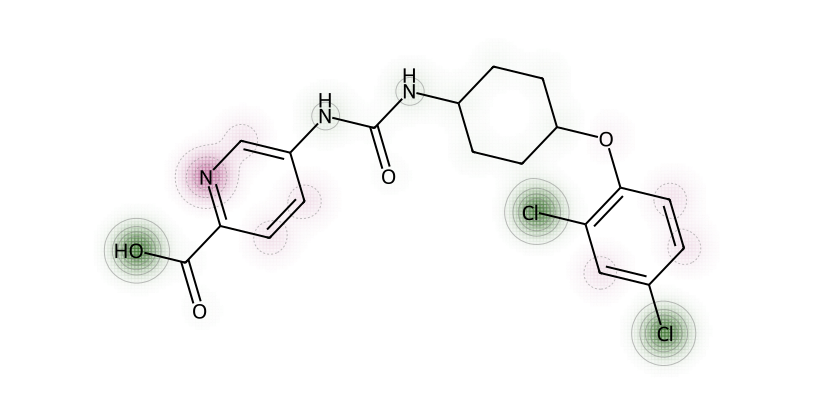

score: 0.38326898217201233


In [15]:
interpret_from_smiles("OC(C1=NC=C(NC(NC2CCC(OC3=C(Cl)C=C(Cl)C=C3)CC2)=O)C=C1)=O", model)

## Testing a series

Attributions for SMILES: OC(C1=NC=C(NC(NC2CCC(OC3=C(Cl)C=C(Cl)C=C3)CC2)=O)C=C1)=O
  ➤ Min attribution: -1.2736
  ➤ Max attribution: 2.0995
  ➤ Mean attribution: 0.1700
  ➤ Attribution convergence delta: -0.000002


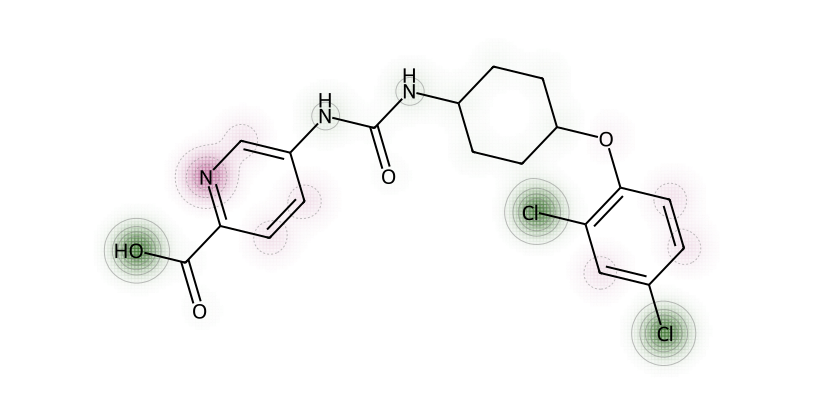

score: 0.38326898217201233


In [ ]:
%autoreload 2
# Example SMILES string
smiles = "OC(C1=NC=C(NC(NC2CCC(OC3=C(Cl)C=C(Cl)C=C3)CC2)=O)C=C1)=O"   # Ronak's compound

interpret_from_smiles(smiles, model)

Attributions for SMILES: OC(C1=CC=C(C=C1)NC(NC2CCC(CC2)OC3=C(C=C(C=C3)Cl)Cl)=O)=O
  ➤ Min attribution: -0.2380
  ➤ Max attribution: 2.3938
  ➤ Mean attribution: 0.1909
  ➤ Attribution convergence delta: -0.000001


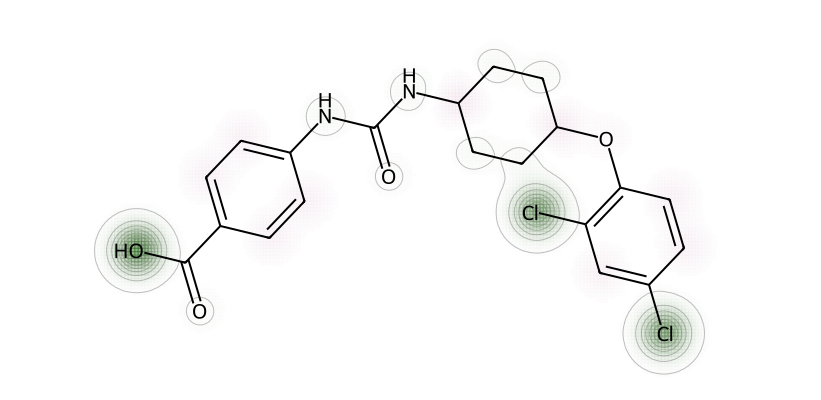

score: 0.5272793769836426


In [18]:
smiles = "OC(C1=CC=C(C=C1)NC(NC2CCC(CC2)OC3=C(C=C(C=C3)Cl)Cl)=O)=O"  

interpret_from_smiles(smiles, model)

Attributions for SMILES: CC(C1=NC=C(C=C1)NC(NC2CCC(CC2)OC3=C(C=C(C=C3)Cl)Cl)=O)=O
  ➤ Min attribution: -1.5110
  ➤ Max attribution: 2.2213
  ➤ Mean attribution: 0.1224
  ➤ Attribution convergence delta: 0.000000


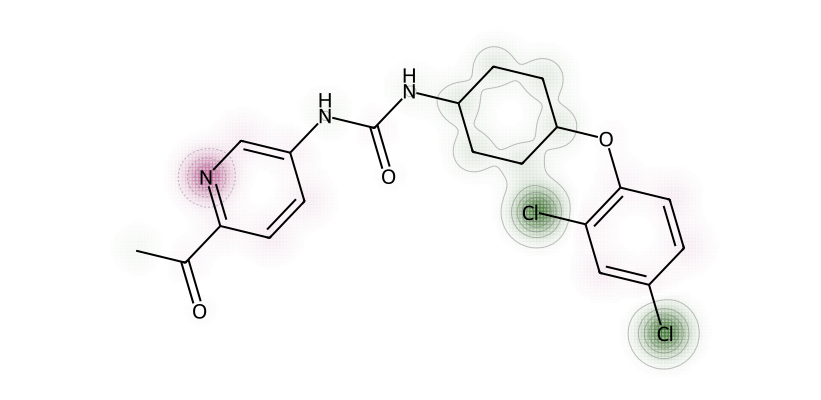

score: 0.14090721309185028


In [19]:
smiles = "CC(C1=NC=C(C=C1)NC(NC2CCC(CC2)OC3=C(C=C(C=C3)Cl)Cl)=O)=O"  

interpret_from_smiles(smiles, model)

Attributions for SMILES: OC(C1=NC=C(C=C1)NC(NC2CCC(CC2)OC3=CC=CC=C3)=O)=O
  ➤ Min attribution: -0.6099
  ➤ Max attribution: 1.6531
  ➤ Mean attribution: 0.1473
  ➤ Attribution convergence delta: -0.000001


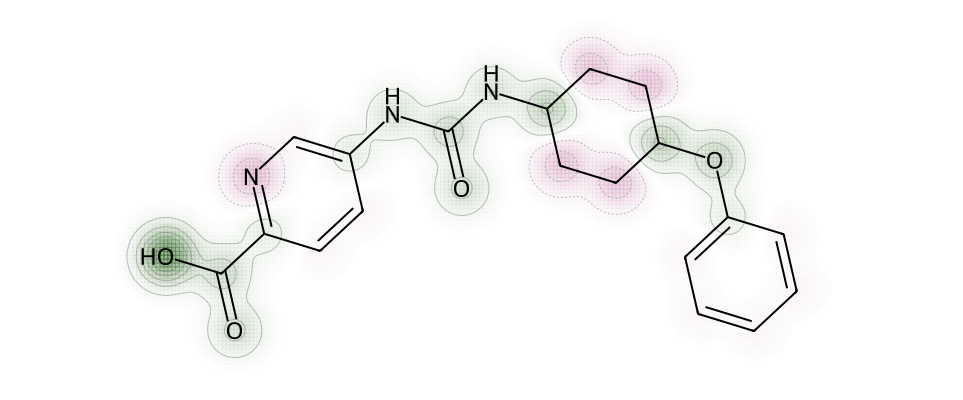

score: 0.19728286564350128


In [20]:
smiles = "OC(C1=NC=C(C=C1)NC(NC2CCC(CC2)OC3=CC=CC=C3)=O)=O"  

interpret_from_smiles(smiles, model)

Attributions for SMILES: OC(C1=NC=C(C=C1)CC(CC2CCC(CC2)OC3=C(C=C(C=C3)Cl)Cl)=O)=O
  ➤ Min attribution: -0.6375
  ➤ Max attribution: 2.3978
  ➤ Mean attribution: 0.1505
  ➤ Attribution convergence delta: 0.000002


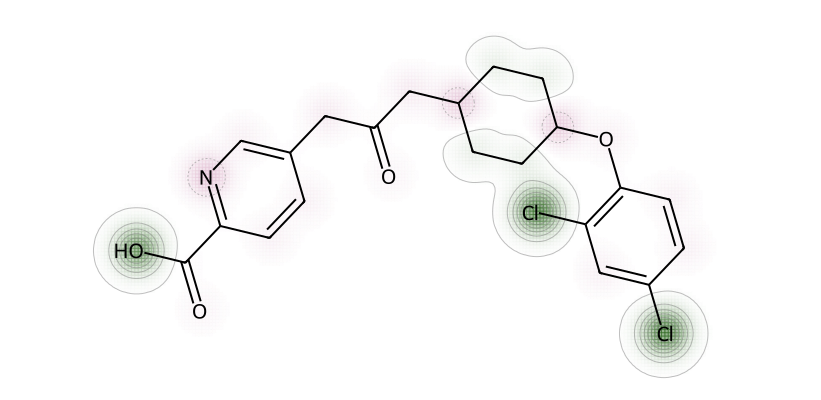

score: 0.26487866044044495


In [21]:
smiles = "OC(C1=NC=C(C=C1)CC(CC2CCC(CC2)OC3=C(C=C(C=C3)Cl)Cl)=O)=O"  

interpret_from_smiles(smiles, model)